# EJERCICIO FINAL PYSPARK (DOCKER + KAFKA + PYSPARK)

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql import functions as F
from pyspark.sql.window import Window


## Creamos la sesión de spark

In [2]:
spark = (
    SparkSession.builder
        .appName("ProyectoIoT")
        .getOrCreate()
)
spark

spark.readStream
Indica que vamos a leer datos en modo streaming, es decir, datos que llegan continuamente.

.format("kafka")
Le decimos a Spark que la fuente de datos de streaming será Kafka.

.option("kafka.bootstrap.servers", "kafka:9092")
Especifica la dirección del clúster Kafka al que conectarse.
En este caso "kafka" es el nombre del contenedor Docker y 9092 es el puerto del broker.

.option("subscribe", "sensores")
Indica el topic de Kafka del que queremos leer mensajes → "sensores".

.option("startingOffsets", "latest")
Define desde qué punto empezar a leer:

"latest" → solo recibe mensajes nuevos, enviados después de iniciar el streaming.

"earliest" sería para leer todos los mensajes antiguos también.

.load()
Ejecuta la configuración y crea un DataFrame de streaming, donde cada fila representa un mensaje recibido desde Kafka.

In [3]:
raw_df = (
    spark.readStream
         .format("kafka")
         .option("kafka.bootstrap.servers", "kafka:9092")  # <-- nombre del contenedor
         .option("subscribe", "sensores")
         .option("startingOffsets", "latest")
         .load()
)


Este bloque transforma los mensajes de Kafka en un formato que Spark puede procesar:

Define la estructura de los datos que esperamos recibir (sensor, valor, temperatura, humedad, estado, timestamp y UUID).

Convierte el JSON recibido en columnas individuales para poder trabajar con cada campo.

Crea una columna de tiempo (event_time) a partir del timestamp original para poder usarlo en ventanas y agregaciones temporales.

In [4]:
schema = StructType([
    StructField("sensor_id", StringType()),
    StructField("value", DoubleType()),
    StructField("temperature", DoubleType()),
    StructField("humidity", DoubleType()),
    StructField("status", StringType()),
    StructField("timestamp", DoubleType()),
    StructField("uuid", StringType())
])

df = raw_df.select(
    from_json(col("value").cast("string"), schema).alias("data")
).select("data.*")

df = df.withColumn("event_time", col("timestamp").cast("timestamp"))


Este bloque realiza agregaciones por ventana de tiempo sobre el DataFrame de streaming:

Define un watermark de 1 minuto para indicar a Spark hasta qué punto los datos antiguos se pueden considerar válidos. Esto ayuda a manejar retrasos y datos tardíos.

Agrupa los datos cada 30 segundos por sensor (sensor_id).

Calcula estadísticas dentro de cada ventana: promedio de valor, temperatura y humedad, y cuenta el número de eventos recibidos.

El resultado es un DataFrame de streaming con resúmenes temporales por sensor listo para análisis o escritura.

In [5]:
agg_df = (
    df
    .withWatermark("event_time", "1 minute")   # ← IMPORTANTE
    .groupBy(
        window(col("event_time"), "30 seconds"),
        col("sensor_id")
    )
    .agg(
        avg("value").alias("avg_value"),
        avg("temperature").alias("avg_temp"),
        avg("humidity").alias("avg_humidity"),
        count("*").alias("num_events")
    )
)


Este bloque escribe los resultados del streaming en archivos Parquet de manera continua:

Define la carpeta de salida donde se guardarán los archivos Parquet (resultados/).

Usa un checkpoint (chk/) para que Spark recuerde qué datos ya procesó y pueda reiniciar de forma segura en caso de fallo.

Modo append: los nuevos datos se agregan continuamente a los archivos existentes.

Inicia el streaming, haciendo que las agregaciones se escriban en tiempo real mientras llegan nuevos datos.

El resultado es un conjunto de archivos Parquet que refleja las métricas agregadas por ventana y por sensor.

In [6]:
parquet_query = (
    agg_df
    .writeStream
    .format("parquet")
    .option("path", "resultados/")
    .option("checkpointLocation", "chk/")
    .outputMode("append")
    .start()
)


A partir de aquí, te toca a ti, sigue las cuestiones planteadas en el Readme y completa el notebook. Despues guardatelo con los outputs de las celdas y súbelo al repo. Mucha suerte que ya lo teneis ;)

### Ejercicio 1: Exploración inicial

Realiza una exploración básica del DataFrame:

- Muestra el esquema completo.
- Indica cuántas filas contiene.- 
¿Cuántos sensores distintos (sensor_id) aparecen?

In [7]:
print("=== Esquema completo ===")
agg_df.printSchema()

resultados_df = spark.read.parquet("resultados/")

print("=== Número de filas ===")
print(resultados_df.count())

print("=== Número de sensores distintios ===")
resultados_df.select(countDistinct(resultados_df.sensor_id)).show()

=== Esquema completo ===
root
 |-- window: struct (nullable = false)
 |    |-- start: timestamp (nullable = true)
 |    |-- end: timestamp (nullable = true)
 |-- sensor_id: string (nullable = true)
 |-- avg_value: double (nullable = true)
 |-- avg_temp: double (nullable = true)
 |-- avg_humidity: double (nullable = true)
 |-- num_events: long (nullable = false)

=== Número de filas ===
2775
=== Número de sensores distintios ===
+-------------------------+
|count(DISTINCT sensor_id)|
+-------------------------+
|                        4|
+-------------------------+



### Ejercicio 2: Transformaciones numéricas

Crea una columna basada en la diferencia o relación entre dos métricas numéricas del DataFrame.


¿Cuál es el valor mínimo, máximo y medio de la nueva columna?

In [8]:
print("=== Columna nueva con la diferencia entre el promedio de humedad y de temperatura (Sin nulos) ===")
diferencia_avg_temp_humidity = resultados_df.withColumn(
    "dif_avg_temp_hum",
    coalesce(col("avg_humidity"), lit(0)) - 
    coalesce(col("avg_temp"), lit(0))
)
diferencia_avg_temp_humidity.show(5)

print("=== Valor mínimo, máximo y medio de la nueva columna (dif_avg_temp_hum) ===")
diferencia_avg_temp_humidity.select(min(diferencia_avg_temp_humidity.dif_avg_temp_hum), 
                                    max(diferencia_avg_temp_humidity.dif_avg_temp_hum), 
                                    mean(diferencia_avg_temp_humidity.dif_avg_temp_hum)).show()

=== Columna nueva con la diferencia entre el promedio de humedad y de temperatura (Sin nulos) ===
+--------------------+---------+------------------+-----------------+------------------+----------+-------------------+
|              window|sensor_id|         avg_value|         avg_temp|      avg_humidity|num_events|   dif_avg_temp_hum|
+--------------------+---------+------------------+-----------------+------------------+----------+-------------------+
|{2025-12-11 17:31...|       S4|30.581428571428575|            61.13|             67.28|         7|  6.149999999999999|
|{2025-12-11 17:31...|       S2|             30.09|45.85285714285714| 62.79285714285714|         7| 16.939999999999998|
|{2025-12-11 11:37...|       S3| 32.63142857142857|71.21285714285715|59.561428571428564|         7|-11.651428571428582|
|{2025-12-11 11:37...|       S4|            25.895|53.50333333333333|63.050000000000004|         6|  9.546666666666674|
|{2025-12-11 14:48...|       S2|36.163333333333334|61.03333333

### Ejercicio 3: Filtrado avanzado

Aplica un filtro usando varias condiciones a la vez relacionadas con:

- humedad- 
número de evento
- 
sensor.

Responde:

¿Cuántos registros cumplen todas las condiciones aplicadas?.

In [10]:
resultadosFiltro_df = resultados_df.filter(col("sensor_id") == "S1").filter(col("num_events") > 11).filter(col("avg_humidity") < 63.87)
resultadosFiltro_df.show(5)

print("=== Número de registros que cumplen las condiciones aplicadas ===")
print(resultadosFiltro_df.count())

+--------------------+---------+------------------+------------------+------------------+----------+
|              window|sensor_id|         avg_value|          avg_temp|      avg_humidity|num_events|
+--------------------+---------+------------------+------------------+------------------+----------+
|{2025-12-11 16:43...|       S1|28.395384615384618| 52.59692307692308| 43.08615384615385|        13|
|{2025-12-11 17:43...|       S1|         33.159375|          54.64375|          57.46625|        16|
|{2025-12-11 18:12...|       S1|30.015000000000004|46.037499999999994|55.020833333333336|        12|
|{2025-12-11 10:52...|       S1|27.646923076923073| 48.55307692307693|58.932307692307695|        13|
|{2025-12-11 11:00...|       S1| 24.46076923076923| 45.73153846153847|54.557692307692314|        13|
+--------------------+---------+------------------+------------------+------------------+----------+
only showing top 5 rows

=== Número de registros que cumplen las condiciones aplicadas ===


### Ejercicio 4: Agregaciones por sensor

Agrupa el DataFrame por "sensor_id" y obten estadísticas descriptivas. 

Responde: 

- ¿Qué sensor tiene la mayor media en la variable analizada?
- ¿Qué sensor presenta la temperatura máxima?
- ¿Cuántos grupos o ventanas existen por sensor?

In [53]:
print("=== Sensor con mayor media en la variable avg_value ===")
media_por_sensor_df = (
    resultados_df
        .groupBy("sensor_id")
        .agg(F.mean("avg_value").alias("media_avg_value"))
        .orderBy(F.desc("media_avg_value"))
)
media_por_sensor_df.show()

=== Sensor con mayor media en la variable avg_value ===
+---------+------------------+
|sensor_id|   media_avg_value|
+---------+------------------+
|       S1|30.082351830626145|
|       S2| 30.05728443914591|
|       S4| 30.01406750937984|
|       S3|29.994016759877173|
+---------+------------------+



In [54]:
print("=== Sensor con temperatura máxima ===")
temp_max_por_sensor_df = (
    resultados_df
        .groupBy("sensor_id")
        .agg(F.max("avg_temp").alias("max_avg_temp"))
        .orderBy(F.desc("max_avg_temp"))
)
temp_max_por_sensor_df.show()

=== Sensor con temperatura máxima ===
+---------+-----------------+
|sensor_id|     max_avg_temp|
+---------+-----------------+
|       S4|           84.985|
|       S3|83.16400000000002|
|       S2|81.57333333333334|
|       S1|79.70714285714287|
+---------+-----------------+



In [23]:
print("=== Grupos o ventanas por sensor ===")
grupos_por_sensor_df = (
    resultados_df
        .groupBy("sensor_id")
        .agg(F.count("sensor_id").alias("grupos_por_sensor"))
        .orderBy(("sensor_id"))
)
grupos_por_sensor_df.show()

=== Grupos o ventanas por sensor ===
+---------+-----------------+
|sensor_id|grupos_por_sensor|
+---------+-----------------+
|       S1|              694|
|       S2|              693|
|       S3|              694|
|       S4|              694|
+---------+-----------------+



### Ejercicio 5: Ranking con funciones de ventana

Usa funciones de ventana para identificar, para cada sensor, el registro con el mayor valor de avg_value.

Responde: 

¿Qué sensor obtiene el valor máximo global entre todos?

In [24]:
ventana = Window.partitionBy("sensor_id").orderBy(F.desc("avg_value"))

ranking_df = resultados_df.withColumn(
    "rn",
    F.row_number().over(ventana)
)

print("=== Registro con mayor avg_value por sensor ===")
max_por_sensor_df = ranking_df.filter(F.col("rn") == 1)
max_por_sensor_df.show()

=== Registro con mayor avg_value por sensor ===
+--------------------+---------+-----------------+-----------------+------------------+----------+---+
|              window|sensor_id|        avg_value|         avg_temp|      avg_humidity|num_events| rn|
+--------------------+---------+-----------------+-----------------+------------------+----------+---+
|{2025-12-11 17:23...|       S1|            46.08|            70.49|             65.47|         1|  1|
|{2025-12-11 18:54...|       S2|            48.69|            34.63|              77.5|         1|  1|
|{2025-12-11 17:33...|       S3|           43.738|           56.866| 51.79600000000001|         5|  1|
|{2025-12-11 15:23...|       S4|44.48142857142857|52.18714285714286|54.269999999999996|         7|  1|
+--------------------+---------+-----------------+-----------------+------------------+----------+---+



In [26]:
max_global = max_por_sensor_df.orderBy(F.desc("avg_value")).first()

sensor_max_global = max_global["sensor_id"]
valor_max_global = max_global["avg_value"]

print("El sensor que obtiene el valor máximo global de avg_value es:",
      sensor_max_global,
      "con avg_value =", valor_max_global)

El sensor que obtiene el valor máximo global de avg_value es: S2 con avg_value = 48.69


### Ejercicio 6: Join con tabla auxiliar

Crea un DataFrame auxiliar con información adicional sobre sensores (por ejemplo, categoría, ubicación o tipo) y realiza un join.

Responde:

Muestra los cinco primeros registros del DataFrame ya unido.

In [27]:
from pyspark.sql import Row

sensores_info = [
    Row(sensor_id="S1", categoria="urbano",      ubicacion="Centro"),
    Row(sensor_id="S2", categoria="industrial",  ubicacion="Puerto"),
    Row(sensor_id="S3", categoria="residencial", ubicacion="Norte"),
    Row(sensor_id="S4", categoria="rural",       ubicacion="Periferia"),
]

sensores_info_df = spark.createDataFrame(sensores_info)

print("=== DataFrame auxiliar de sensores ===")
sensores_info_df.show()

=== DataFrame auxiliar de sensores ===
+---------+-----------+---------+
|sensor_id|  categoria|ubicacion|
+---------+-----------+---------+
|       S1|     urbano|   Centro|
|       S2| industrial|   Puerto|
|       S3|residencial|    Norte|
|       S4|      rural|Periferia|
+---------+-----------+---------+



In [29]:
joinCondition = resultados_df.sensor_id == sensores_info_df.sensor_id

resultados_con_info_df = (
    resultados_df
        .join(sensores_info_df, joinCondition, "left")  
        .drop(sensores_info_df.sensor_id)            
)

print("=== Verificación del DF unido ===")
resultados_con_info_df.show(5)

=== Verificación del DF unido ===
+--------------------+---------+------------------+-----------------+------------------+----------+-----------+---------+
|              window|sensor_id|         avg_value|         avg_temp|      avg_humidity|num_events|  categoria|ubicacion|
+--------------------+---------+------------------+-----------------+------------------+----------+-----------+---------+
|{2025-12-11 17:31...|       S4|30.581428571428575|            61.13|             67.28|         7|      rural|Periferia|
|{2025-12-11 11:37...|       S4|            25.895|53.50333333333333|63.050000000000004|         6|      rural|Periferia|
|{2025-12-11 11:37...|       S3| 32.63142857142857|71.21285714285715|59.561428571428564|         7|residencial|    Norte|
|{2025-12-11 17:31...|       S2|             30.09|45.85285714285714| 62.79285714285714|         7| industrial|   Puerto|
|{2025-12-11 14:48...|       S2|36.163333333333334|61.03333333333334|             61.31|         6| industrial| 

### Ejercicio 7: Agrupación por ventana temporal

Extrae la marca de inicio de la ventana y agrúpala por unidades de tiempo truncadas (p. ej., minuto u hora).

Responde: 

- ¿Cuántas ventanas hay por unidad temporal?
- ¿Cuál es la humedad media por cada unidad?

In [33]:
resultados_con_inicio = resultados_df.withColumn(
    "window_start",
    F.col("window.start")
)

resultados_trunc = resultados_con_inicio.withColumn(
    "window_start_trunc",
    F.date_trunc("minute", F.col("window_start"))
)

ventanas_por_unidad = (
    resultados_trunc
        .groupBy("window_start_trunc")
        .agg(
            F.countDistinct("window_start").alias("num_ventanas")
        )
        .orderBy("window_start_trunc")
)

print("=== Número de ventanas por unidad temporal ===")
ventanas_por_unidad.show(5)

=== Número de ventanas por unidad temporal ===
+-------------------+------------+
| window_start_trunc|num_ventanas|
+-------------------+------------+
|2025-12-11 10:25:00|           2|
|2025-12-11 10:26:00|           2|
|2025-12-11 10:27:00|           2|
|2025-12-11 10:28:00|           2|
|2025-12-11 10:29:00|           2|
+-------------------+------------+
only showing top 5 rows



In [34]:
humedad_por_unidad = (
    resultados_trunc
        .groupBy("window_start_trunc")
        .agg(
            F.countDistinct("window_start").alias("num_ventanas"),
            F.avg("avg_humidity").alias("humedad_media")
        )
        .orderBy("window_start_trunc")
)

print("=== Ventanas y humedad media por unidad temporal ===")
humedad_por_unidad.show(5)

=== Ventanas y humedad media por unidad temporal ===
+-------------------+------------+------------------+
| window_start_trunc|num_ventanas|     humedad_media|
+-------------------+------------+------------------+
|2025-12-11 10:25:00|           2| 56.69582670454545|
|2025-12-11 10:26:00|           2|59.857299679487184|
|2025-12-11 10:27:00|           2|54.852284090909095|
|2025-12-11 10:28:00|           2| 53.37181746031746|
|2025-12-11 10:29:00|           2| 55.11489148351649|
+-------------------+------------+------------------+
only showing top 5 rows



### Ejercicio 8: Repartición y particiones

Reparte el DataFrame por sensor_id y añade una columna indicando el identificador de partición.

Responde: 

¿Cuál es la distribución de registros entre las particiciones?

In [46]:
resultados_repartidos = resultados_df.repartition(4, "sensor_id")

resultados_con_particion = resultados_repartidos.withColumn(
    "partition_id",
    F.spark_partition_id()
)

resultados_con_particion.show()

+--------------------+---------+------------------+------------------+------------------+----------+------------+
|              window|sensor_id|         avg_value|          avg_temp|      avg_humidity|num_events|partition_id|
+--------------------+---------+------------------+------------------+------------------+----------+------------+
|{2025-12-11 11:37...|       S3| 32.63142857142857| 71.21285714285715|59.561428571428564|         7|           0|
|{2025-12-11 15:47...|       S3|            25.548|            56.725|            49.592|        10|           0|
|{2025-12-11 16:43...|       S3|21.838333333333335|55.973333333333336|51.669999999999995|         6|           0|
|{2025-12-11 17:43...|       S3|             28.58| 59.24333333333333| 78.50333333333333|         3|           0|
|{2025-12-11 18:01...|       S3|28.784000000000002|55.512000000000015|            52.575|        10|           0|
|{2025-12-11 18:36...|       S3|33.096666666666664|51.190000000000005| 65.82777777777777

In [47]:
distribucion_df = (
    resultados_con_particion
        .groupBy("partition_id")
        .agg(F.count("*").alias("num_registros"))
        .orderBy("partition_id")
)

print("=== Distribución de registros por partición ===")
distribucion_df.show()

=== Distribución de registros por partición ===
+------------+-------------+
|partition_id|num_registros|
+------------+-------------+
|           0|          694|
|           1|         1387|
|           3|          694|
+------------+-------------+



### Ejercicio 9: Detección de anomalías

Define un criterio personalizado de "anomalía" basado en los valores medios del DataFrame.

Responde: 

- ¿Cuántos registros son anómalos?
- ¿Qué sensor tiene más anomalías?

In [37]:
#Consideramos anómalo un registro cuando su avg_value está muy alejado de la media global, más de 2 desviaciones estándar por encima o por debajo.
stats = resultados_df.select(
    F.mean("avg_value").alias("mean_val"),
    F.stddev("avg_value").alias("std_val")
).collect()[0]

mean_val = stats["mean_val"]
std_val  = stats["std_val"]

lower_bound = mean_val - 2 * std_val
upper_bound = mean_val + 2 * std_val

print("Media avg_value:", mean_val)
print("Desviación estándar avg_value:", std_val)
print("Umbral inferior:", lower_bound)
print("Umbral superior:", upper_bound)

Media avg_value: 30.0369227998728
Desviación estándar avg_value: 4.602194863905217
Umbral inferior: 20.83253307206237
Umbral superior: 39.241312527683235


In [43]:
resultados_con_anom = resultados_df.withColumn(
    "es_anomalia",
    (F.col("avg_value") < lower_bound) | (F.col("avg_value") > upper_bound)
)

resultados_con_anom.show(5)

+--------------------+---------+------------------+-----------------+------------------+----------+-----------+
|              window|sensor_id|         avg_value|         avg_temp|      avg_humidity|num_events|es_anomalia|
+--------------------+---------+------------------+-----------------+------------------+----------+-----------+
|{2025-12-11 17:31...|       S4|30.581428571428575|            61.13|             67.28|         7|      false|
|{2025-12-11 17:31...|       S2|             30.09|45.85285714285714| 62.79285714285714|         7|      false|
|{2025-12-11 11:37...|       S3| 32.63142857142857|71.21285714285715|59.561428571428564|         7|      false|
|{2025-12-11 11:37...|       S4|            25.895|53.50333333333333|63.050000000000004|         6|      false|
|{2025-12-11 14:48...|       S2|36.163333333333334|61.03333333333334|             61.31|         6|      false|
+--------------------+---------+------------------+-----------------+------------------+----------+-----

In [40]:
num_anomalias = (
    resultados_con_anom
        .filter(F.col("es_anomalia"))
        .count()
)

print("Número de registros anómalos:", num_anomalias)

Número de registros anómalos: 131


In [49]:
anom_por_sensor = (
    resultados_con_anom
        .filter(F.col("es_anomalia"))
        .groupBy("sensor_id")
        .agg(F.count("*").alias("num_anomalias"))
        .orderBy(F.desc("num_anomalias"))
)

print("=== Anomalías por sensor ===")
anom_por_sensor.show()

=== Anomalías por sensor ===
+---------+-------------+
|sensor_id|num_anomalias|
+---------+-------------+
|       S2|           37|
|       S1|           35|
|       S3|           31|
|       S4|           28|
+---------+-------------+



### Ejercicio 10: Cruce de métricas

Crea una puntuación combinando varias columnas del DataFrame (por ejemplo, ponderando avg_value, temperatura y humedad).

Responde: 

- ¿Qué sensor obtiene la puntuación más alta?
- ¿Cuál es el valor de dicha puntuación?

In [50]:
resultados_con_score = resultados_df.withColumn(
    "score",
    0.5 * F.col("avg_value") + 
    0.3 * F.col("avg_temp") - 
    0.2 * F.col("avg_humidity")
)

resultados_con_score.select("sensor_id", "avg_value", "avg_temp", "avg_humidity", "score").show(5)

+---------+------------------+-----------------+------------------+------------------+
|sensor_id|         avg_value|         avg_temp|      avg_humidity|             score|
+---------+------------------+-----------------+------------------+------------------+
|       S4|30.581428571428575|            61.13|             67.28|20.173714285714283|
|       S2|             30.09|45.85285714285714| 62.79285714285714|16.242285714285714|
|       S3| 32.63142857142857|71.21285714285715|59.561428571428564|25.767285714285713|
|       S4|            25.895|53.50333333333333|63.050000000000004|           16.3885|
|       S2|36.163333333333334|61.03333333333334|             61.31|24.129666666666665|
+---------+------------------+-----------------+------------------+------------------+
only showing top 5 rows



In [51]:
mejores_scores_df = (
    resultados_con_score
        .groupBy("sensor_id")
        .agg(F.mean("score").alias("score_medio"))
        .orderBy(F.desc("score_medio"))
)

print("=== Puntuación media por sensor ===")
mejores_scores_df.show()

top = mejores_scores_df.first()
sensor_top = top["sensor_id"]
score_top  = top["score_medio"]

print("El sensor con mayor puntuación es:", sensor_top)
print("Su puntuación es:", score_top)

=== Puntuación media por sensor ===
+---------+------------------+
|sensor_id|       score_medio|
+---------+------------------+
|       S4|20.612846756217685|
|       S1| 20.57651689604224|
|       S2| 20.54559382526644|
|       S3|20.391354751356545|
+---------+------------------+

El sensor con mayor puntuación es: S4
Su puntuación es: 20.612846756217685


### Ejercicio 11: Graficar DF

Crea dos gráficos, convirtiendo el DF de spark a pandas y utiliza la libreria matplotlib para generar dos gráficos sobre alguna de las variables.

In [52]:
import matplotlib.pyplot as plt

pdf = (
    resultados_df
    .selectExpr("sensor_id",
                "avg_value",
                "avg_temp",
                "avg_humidity",
                "window.start as window_start")
    .toPandas()
)

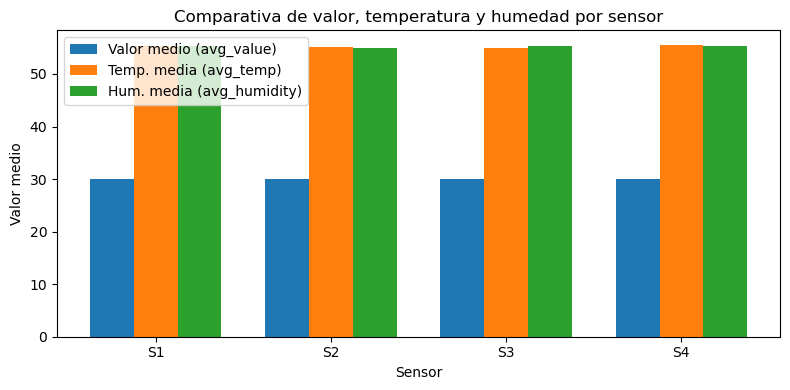

In [60]:
import numpy as np

sensor_stats = (
    pdf.groupby("sensor_id")[["avg_value", "avg_temp", "avg_humidity"]]
       .mean()
       .reset_index()
)


x = np.arange(len(sensor_stats["sensor_id"]))  # S1, S2, S3, S4
width = 0.25

plt.figure(figsize=(8,4))

plt.bar(x - width, sensor_stats["avg_value"],  width, label="Valor medio (avg_value)")
plt.bar(x,          sensor_stats["avg_temp"],   width, label="Temp. media (avg_temp)")
plt.bar(x + width,  sensor_stats["avg_humidity"], width, label="Hum. media (avg_humidity)")

plt.xticks(x, sensor_stats["sensor_id"])
plt.xlabel("Sensor")
plt.ylabel("Valor medio")
plt.title("Comparativa de valor, temperatura y humedad por sensor")
plt.legend()
plt.tight_layout()
plt.show()

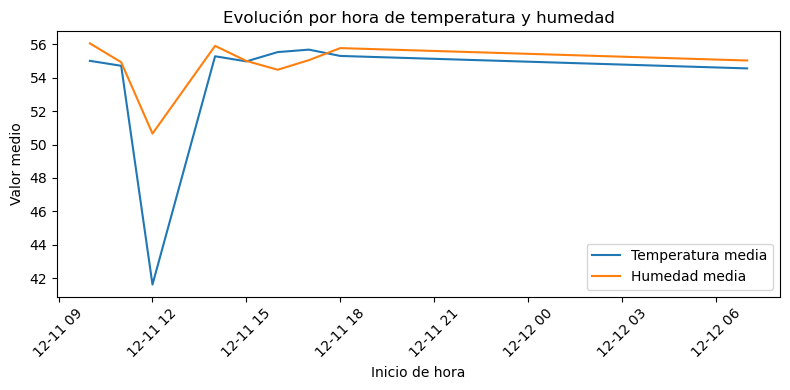

In [61]:
pdf["window_hour"] = pdf["window_start"].dt.floor("H")

agg_time = (
    pdf.groupby("window_hour")[["avg_temp", "avg_humidity"]]
       .mean()
       .reset_index()
       .sort_values("window_hour")
)

plt.figure(figsize=(8,4))
plt.plot(agg_time["window_hour"], agg_time["avg_temp"], label="Temperatura media")
plt.plot(agg_time["window_hour"], agg_time["avg_humidity"], label="Humedad media")
plt.xlabel("Inicio de hora")
plt.ylabel("Valor medio")
plt.title("Evolución por hora de temperatura y humedad")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()